# Итоговое задание

**Traffic Prediction**

Датасет: https://github.com/MVRonkin/TimeSeriesCourse/blob/fd0f3aeec3bfe81887226bc668e4e1a7cefb0dd2/OLD%20Versions/2026/datasets/Traffic%20Prediction/traffic-prediction-custom-gru-lstm-cnn-mlp.ipynb$0

## Подготовка данных и EDA

### Подготовка датасета

In [1]:
# установка необходимых библиотек
import os
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from pandas.tseries.holiday import USFederalHolidayCalendar
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

In [2]:
#загрузка данных
df = pd.read_csv('https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/fd0f3aeec3bfe81887226bc668e4e1a7cefb0dd2/OLD%20Versions/2026/datasets/Traffic%20Prediction/traffic.csv')

In [3]:
# информация о датасете
print('Описание датасета')
print()
print(df.head(5))
print('-'*20)
print()
print(df.info())
print('-'*20)
print()
print('Статистика')
print(df.describe())
print('-'*20)
print()
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок")
print()
print('-'*20)
print(f'Названия колонок: {df.columns.tolist()}')
print('-'*20)
print()
# Проверка на пропуски
print(f"Пропуски:\n\n{df.isnull().sum()}")
print('-'*20)
print(f'Монтонность: {df.index.is_monotonic_increasing}')
print(f'Дубликаты: {df.index.has_duplicates}')
print('-'*20)
print()
print(f'Примеры строк:\n\n{df.sample(5, random_state=0)}')

Описание датасета

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
--------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
--------------------

Статистика
           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min    

In [4]:
# Удаляем колонку ID
df.drop('ID', axis=1, inplace=True)

In [5]:
# устанавливаем новый индекс в формате DateTime
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)
print(f'Тип нового индекса: {type(df.index)}')

Тип нового индекса: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [6]:
# Общая статистика
print(f"Период данных: с {df.index.min()} по {df.index.max()}")
print(f"Частота данных: {df.index.inferred_freq}")

print(f"Всего перекрёстков: {df['Junction'].nunique()}")
print(f"Список перекрёстков: {sorted(df['Junction'].unique())}")

print("\nЗаписей на каждом перекрёстке:")
print(df['Junction'].value_counts().sort_index())

print("\nСреднее количество машин на перекрёстке:")
print(df.groupby('Junction')['Vehicles'].mean().round(2))

Период данных: с 2015-11-01 00:00:00 по 2017-06-30 23:00:00
Частота данных: None
Всего перекрёстков: 4
Список перекрёстков: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Записей на каждом перекрёстке:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

Среднее количество машин на перекрёстке:
Junction
1    45.05
2    14.25
3    13.69
4     7.25
Name: Vehicles, dtype: float64


In [7]:
# проверка регулярности шагов
df = df.sort_index()
dt = df.index.to_series().diff().value_counts()
print(dt.head())

DateTime
0 days 00:00:00    33528
0 days 01:00:00    14591
Name: count, dtype: int64


**Основные характеристики ВР**

- В датасете представлены данные о количестве машин на 4 перекрестах. Замеры идут каждый час. Для 3 перекрестков - длительность временного ряда/количество календарных дней: 608, для четвертого: 181 день.
- Пропусков нет, шаги идут регулярно.

### Визуализация ВР

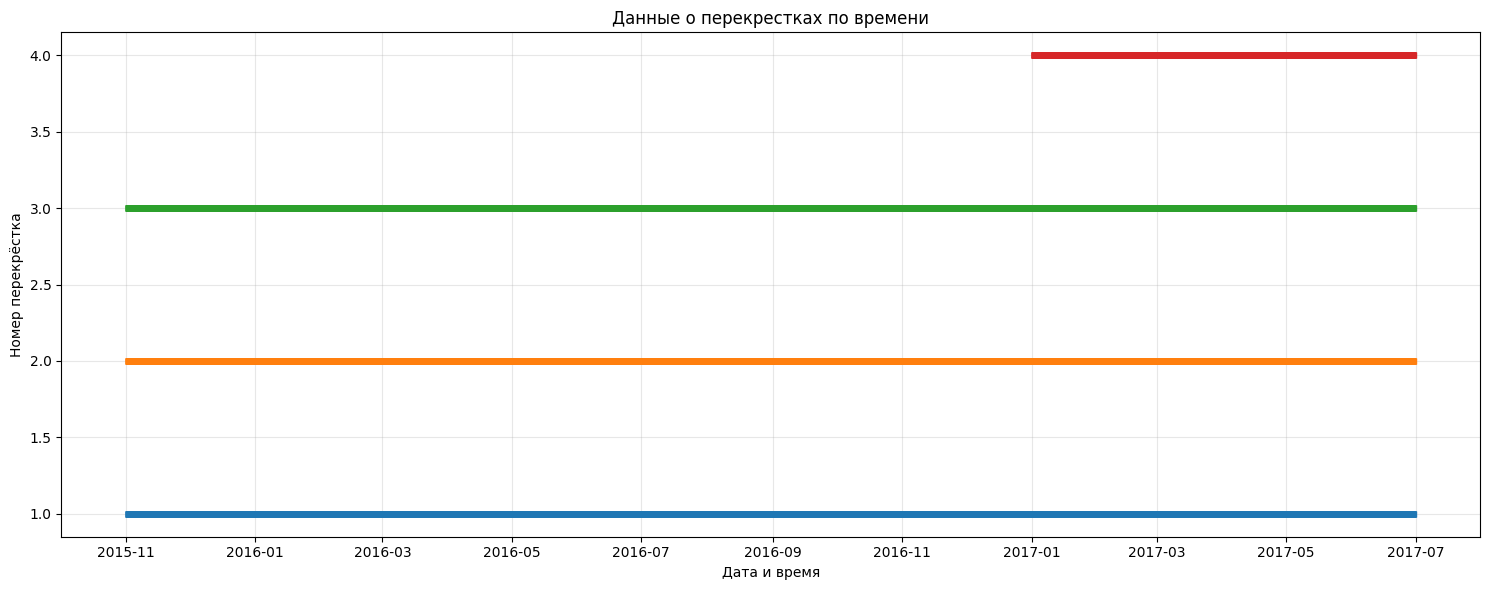

In [8]:
plt.figure(figsize=(15, 6))
df_sorted = df.sort_index()
for junction in df_sorted['Junction'].unique():
    data = df_sorted[df_sorted['Junction'] == junction]
    plt.plot(data.index, [junction] * len(data), '|', markersize=5, label=f'Junction {junction}')

plt.title('Данные о перекрестках по времени')
plt.ylabel('Номер перекрёстка')
plt.xlabel('Дата и время')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

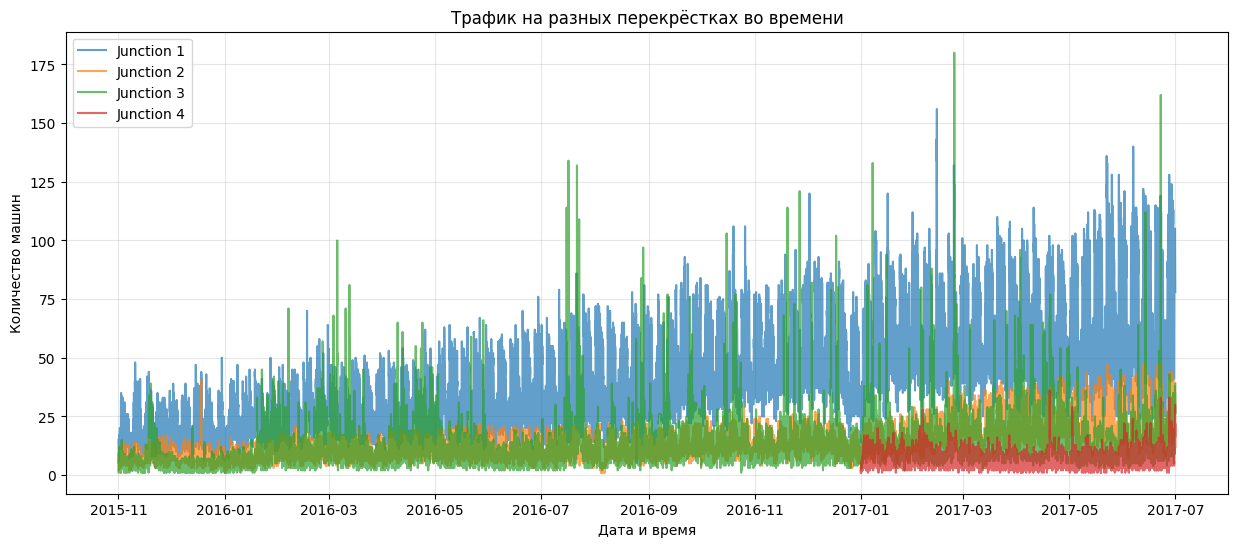

In [9]:
# Графики вместе
plt.figure(figsize=(15, 6))

for junction in df['Junction'].unique():
    data = df[df['Junction'] == junction]
    plt.plot(data.index, data['Vehicles'], label=f'Junction {junction}', alpha=0.7)

plt.title('Трафик на разных перекрёстках во времени')
plt.xlabel('Дата и время')
plt.ylabel('Количество машин')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

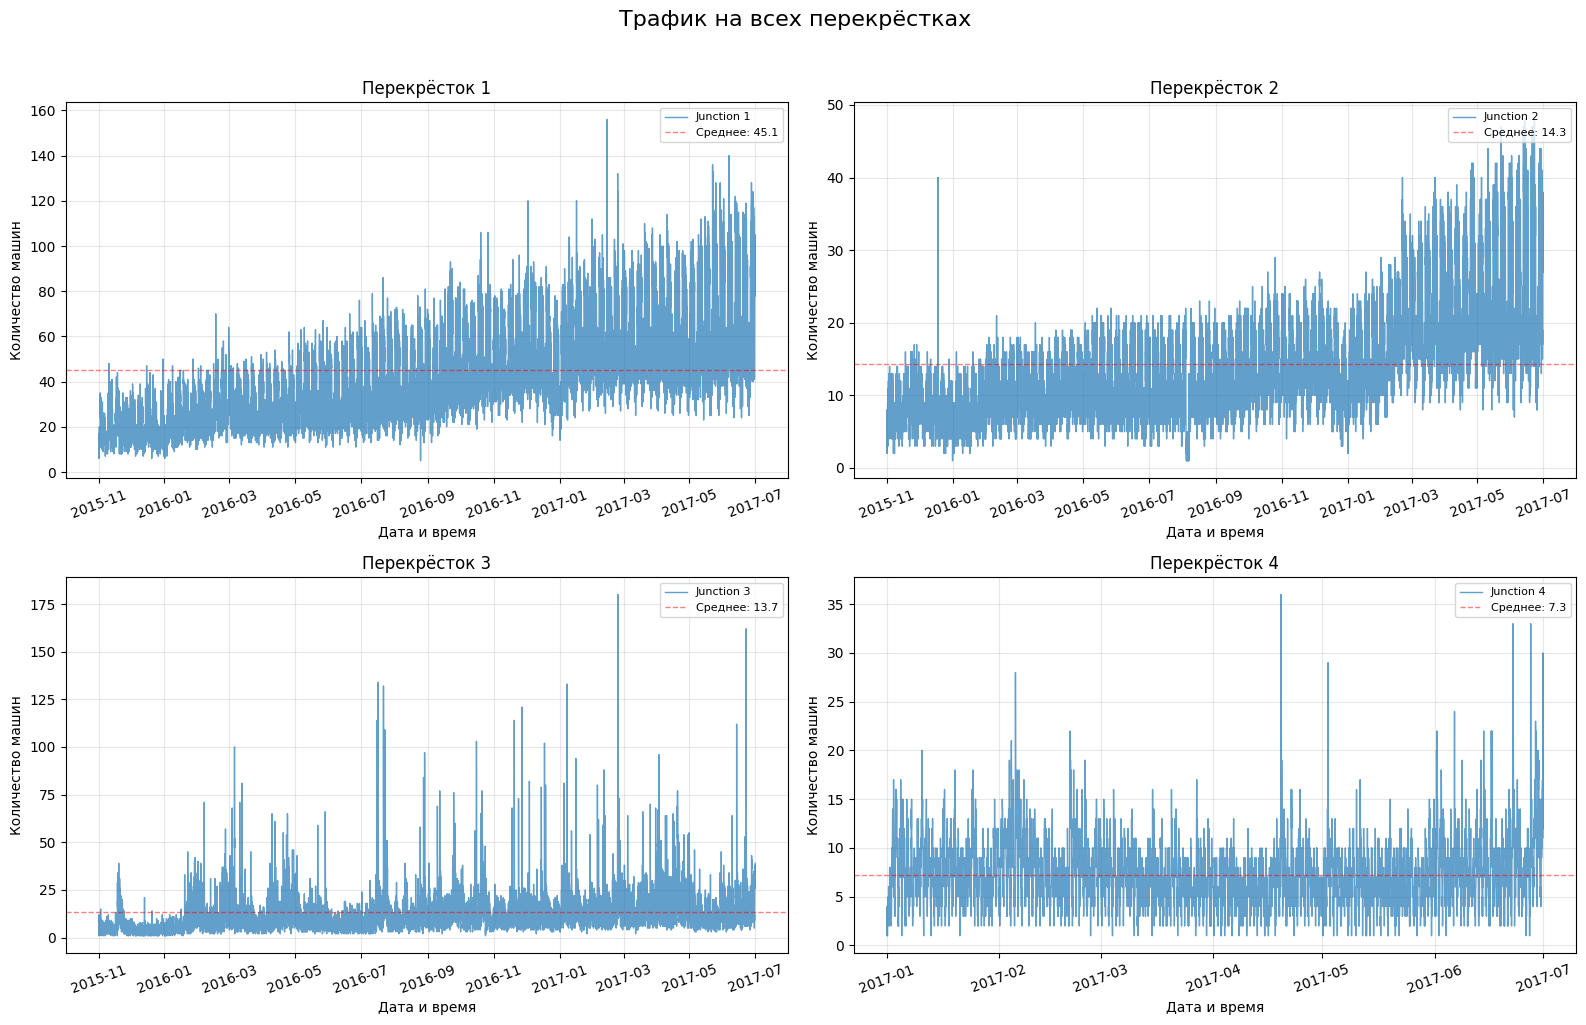

In [10]:
# графики раздельно
junctions = sorted(df['Junction'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 5 * 2))
axes = axes.flatten()

for i, junction in enumerate(junctions):
    data = df[df['Junction'] == junction]

    axes[i].plot(data.index, data['Vehicles'], linewidth=1, alpha=0.7, label=f'Junction {junction}')

    mean_val = data['Vehicles'].mean()
    axes[i].axhline(y=mean_val, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Среднее: {mean_val:.1f}')

    axes[i].set_title(f'Перекрёсток {junction}', fontsize=12)
    axes[i].set_xlabel('Дата и время')
    axes[i].set_ylabel('Количество машин')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Трафик на всех перекрёстках', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Визуальная оценка ВР**
- На перекрестках различный трафик
- На 1 тренд растет. Возможно, это транспортное направление становится более популярным. Сравнительно с тремя другими он намного более популярный - в среднем 45,1 машина в час.
- На 2 тренд также растет, но перекресток примерно в три раза менее загружен (в среднем 14,3 машины).
- На 3 перекрестке загруженность близка ко 2 (среднее: 13.7), но нет восходящего тренда. При этом весьма ощутимы выбросы: в 2-3 раза больше среднего количества машин.
- На 4 перекрестке в среднем зафиксировано 7,3 машины. Восходящего тренда нет. Заметны выбросы.

Все 4 ВР необходимо оценивать отдельно.

### Ресеплируем по неделям и месяцам + посмотрим празники и выходные

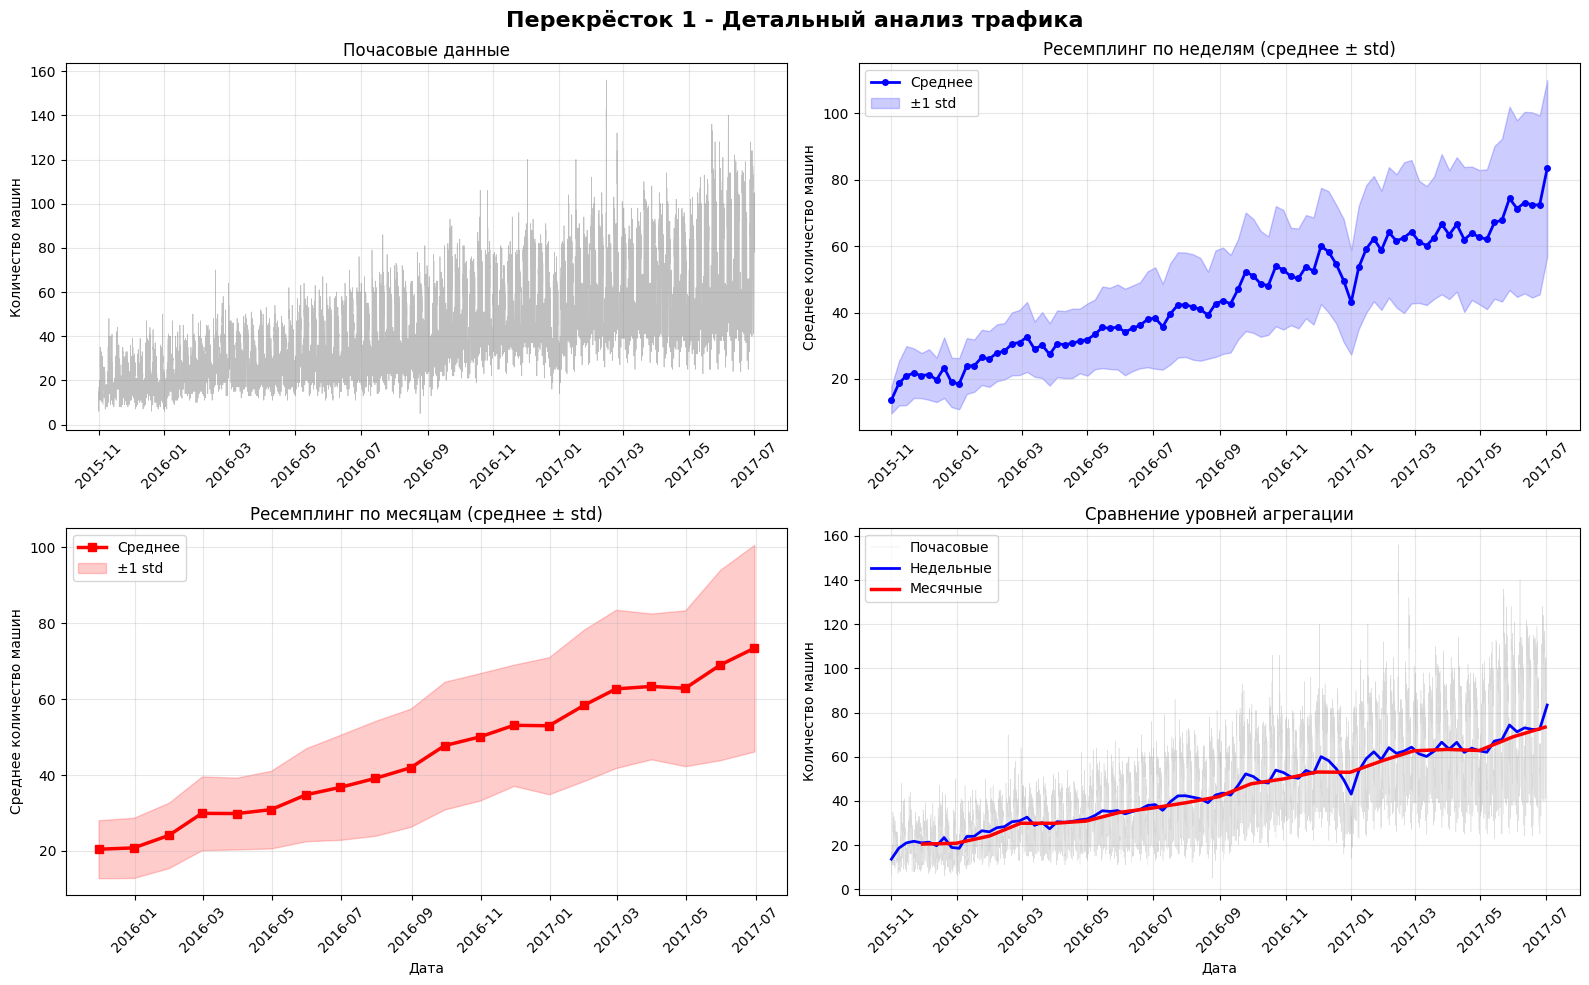

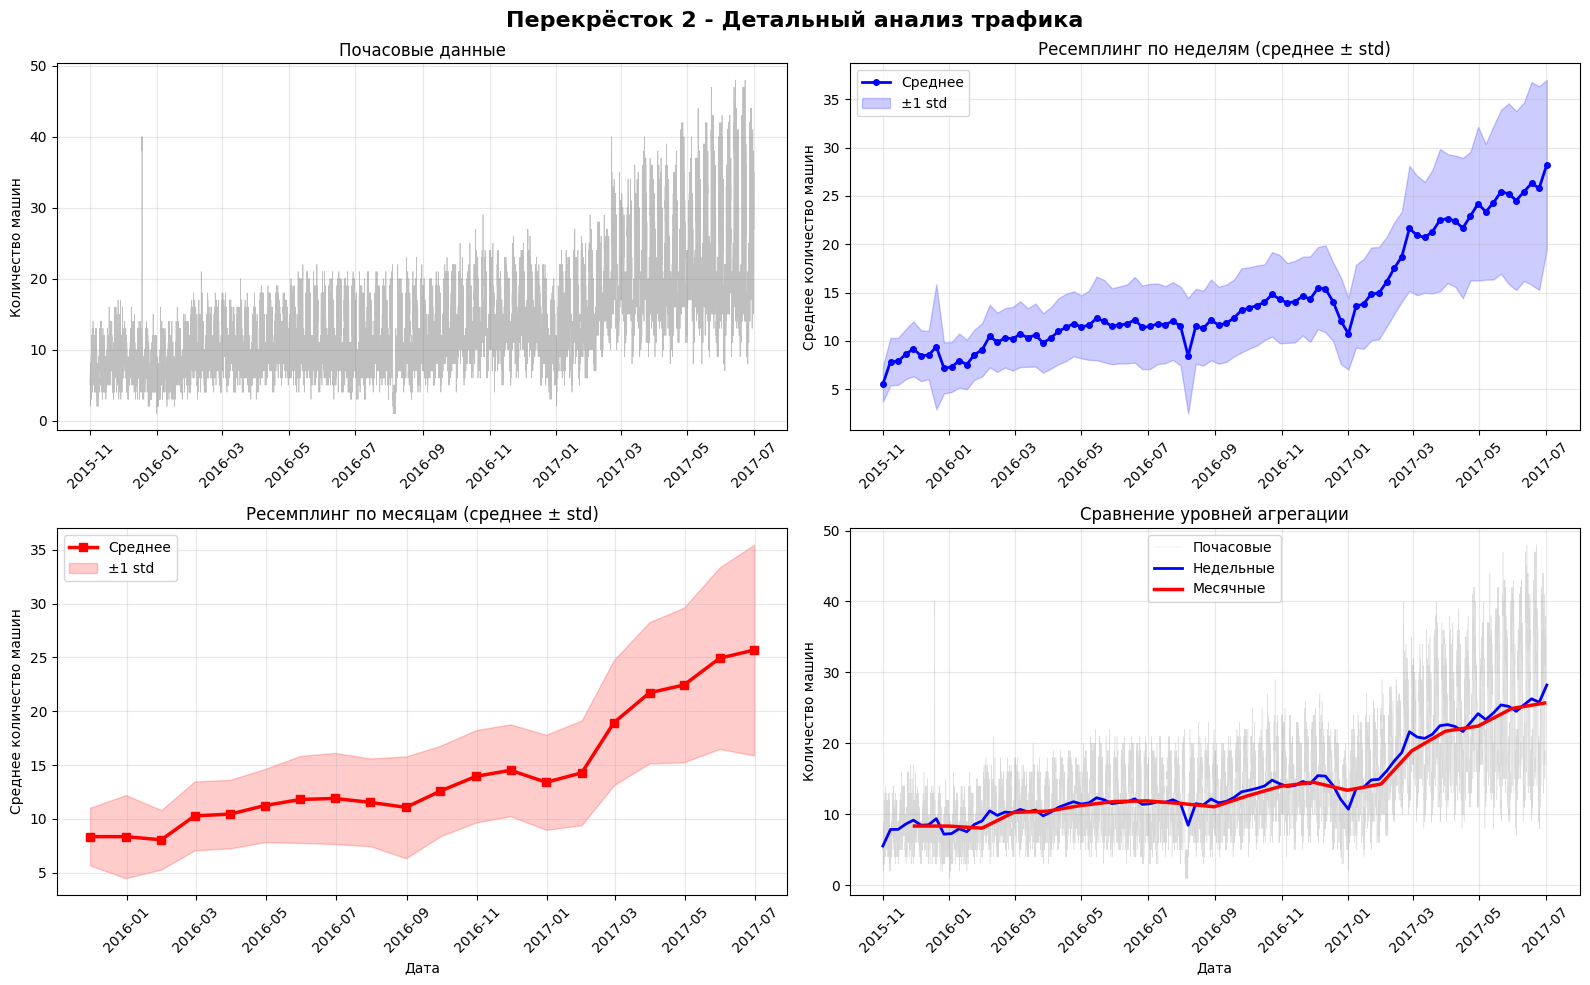

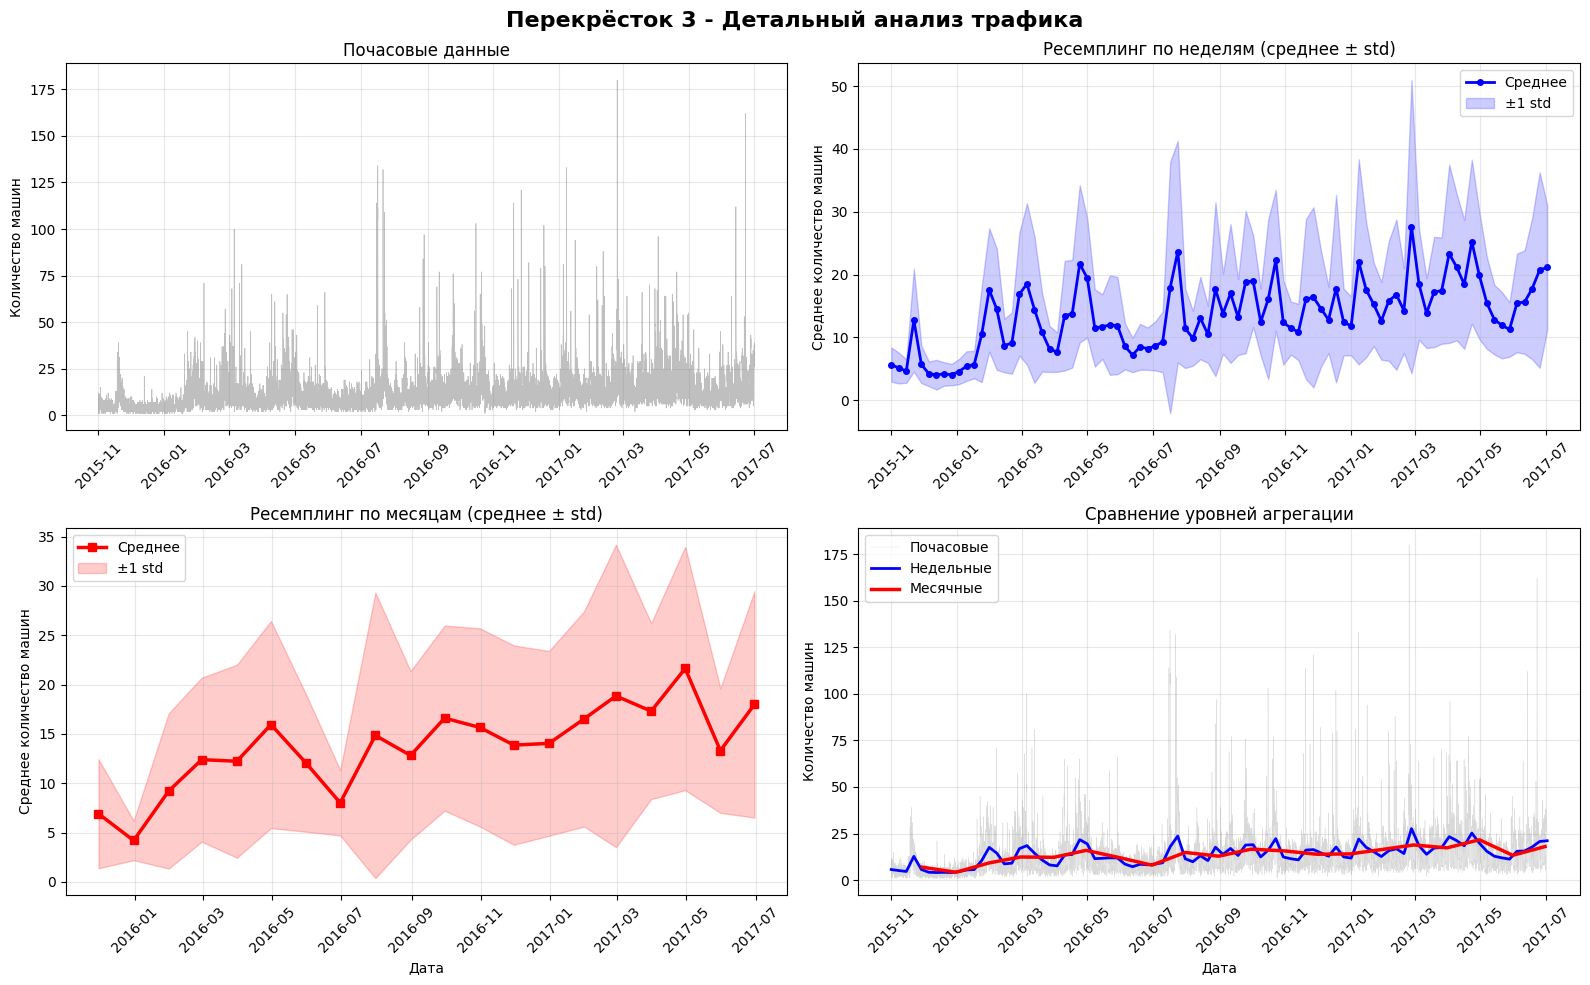

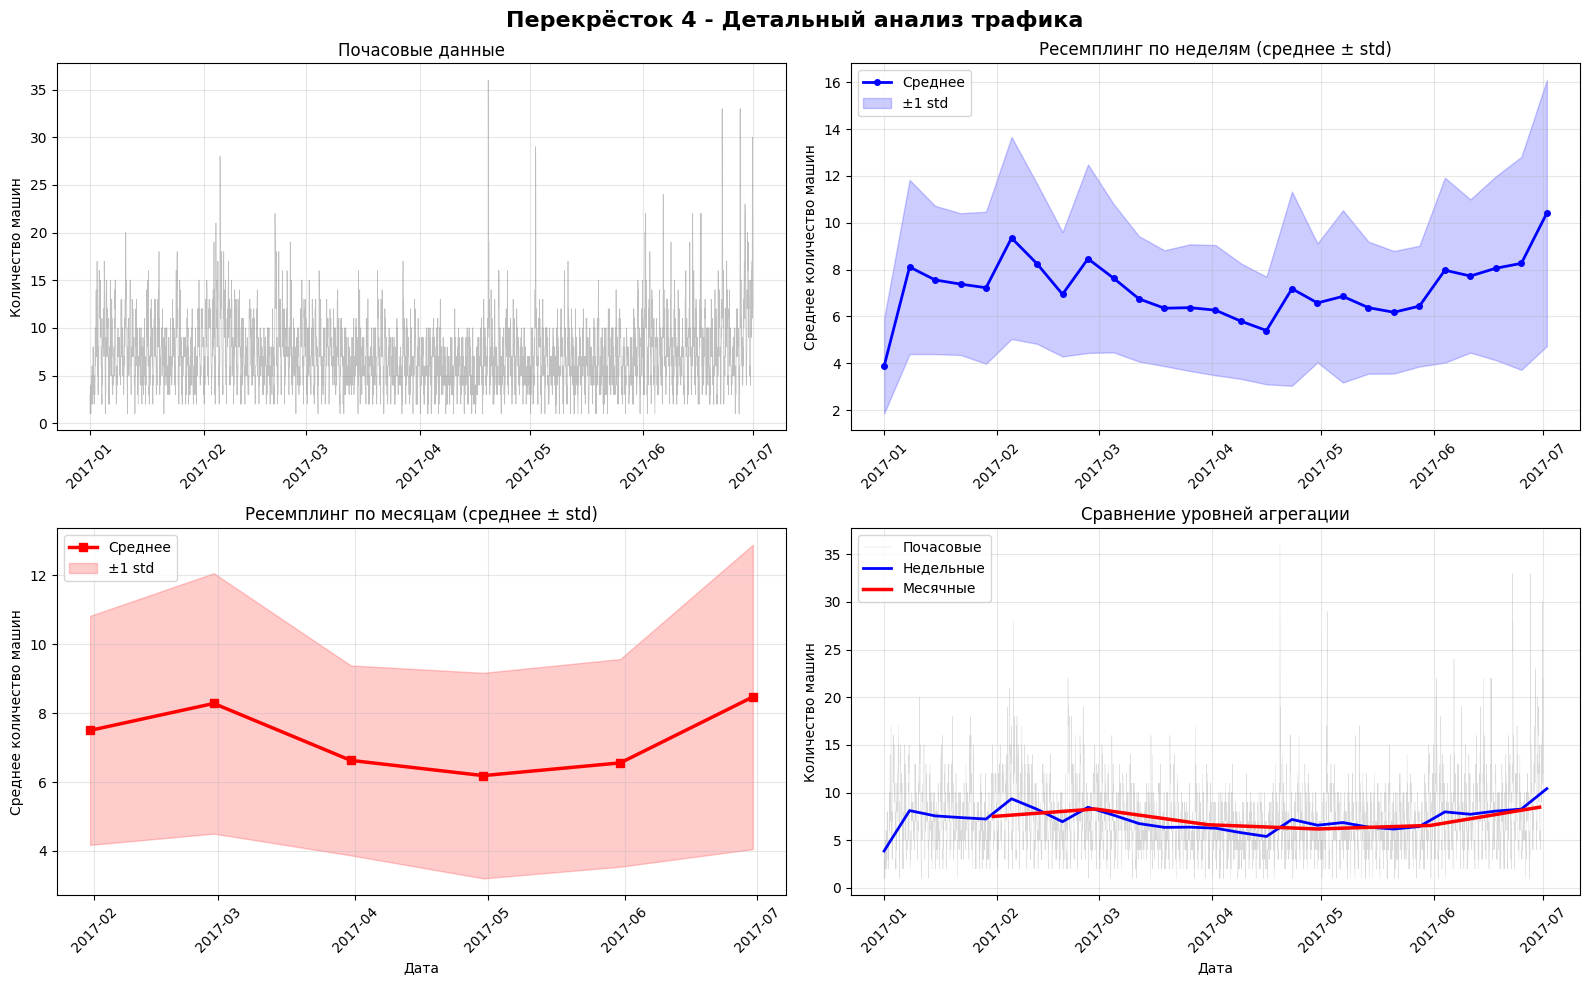

In [11]:
df_work = df_sorted.copy()

for junction in junctions:
    data = df_work[df_work['Junction'] == junction]['Vehicles'].copy()

    # Ресемплинг с разными агрегациями
    weekly_mean = data.resample('W').mean()
    weekly_std = data.resample('W').std()
    monthly_mean = data.resample('ME').mean()
    monthly_std = data.resample('ME').std()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Перекрёсток {junction} - Детальный анализ трафика', fontsize=16, fontweight='bold')

    # 1. Исходные данные
    axes[0, 0].plot(data.index, data.values, linewidth=0.5, alpha=0.5, color='gray')
    axes[0, 0].set_title('Почасовые данные', fontsize=12)
    axes[0, 0].set_ylabel('Количество машин')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Недельный ресемплинг (среднее + std)
    axes[0, 1].plot(weekly_mean.index, weekly_mean.values, linewidth=2, color='blue', marker='o', markersize=4, label='Среднее')
    axes[0, 1].fill_between(weekly_mean.index,
                            weekly_mean.values - weekly_std.values,
                            weekly_mean.values + weekly_std.values,
                            alpha=0.2, color='blue', label='±1 std')
    axes[0, 1].set_title('Ресемплинг по неделям (среднее ± std)', fontsize=12)
    axes[0, 1].set_ylabel('Среднее количество машин')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Месячный ресемплинг (среднее + std)
    axes[1, 0].plot(monthly_mean.index, monthly_mean.values, linewidth=2.5, color='red', marker='s', markersize=6, label='Среднее')
    axes[1, 0].fill_between(monthly_mean.index,
                            monthly_mean.values - monthly_std.values,
                            monthly_mean.values + monthly_std.values,
                            alpha=0.2, color='red', label='±1 std')
    axes[1, 0].set_title('Ресемплинг по месяцам (среднее ± std)', fontsize=12)
    axes[1, 0].set_ylabel('Среднее количество машин')
    axes[1, 0].set_xlabel('Дата')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Сравнение всех уровней ресемплинга на одном графике
    axes[1, 1].plot(data.index, data.values, linewidth=0.3, alpha=0.3, color='gray', label='Почасовые')
    axes[1, 1].plot(weekly_mean.index, weekly_mean.values, linewidth=2, color='blue', label='Недельные')
    axes[1, 1].plot(monthly_mean.index, monthly_mean.values, linewidth=2.5, color='red', label='Месячные')
    axes[1, 1].set_title('Сравнение уровней агрегации', fontsize=12)
    axes[1, 1].set_ylabel('Количество машин')
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

1.   ПРЕКРЕСТОК 1

При ресемплинге по неделям явно виден восходящий тренд. Значительное провисание приходится на Новогоднее время 2016 и 2017 гг. Есть и другие колебания. Их нужно будет анализировать отдельно. На графике респемлинга по годам тренд видет еще ярче.

2.   ПРЕКРЕСТОК 2

При ресемплинге по неделям видна схожая картина - рост загруженности перекрестка. Довольно значительный провал на Новый год и в промежуток с 2016-07 и 2016-09.

3.   ПРЕКРЕСТОК 3

На графика ресемплинга по неделям видно множество колебаний. На графике динамики трафика по месяцам обнаружился возрастающий тренд: на начало периода среднее > 5, на конец > 15. Рост есть, хотя, конечно, не такой сильный как на перекрестках 1-2. На этом перекрестке ярковыраженного спада в Новый год мы не наблюдаем.

4.   ПРЕКРЕСТОК 4

На графике ресемплинга по неделям видны колебания. По месяцам - график довольно плавный, можно предположить, что график близок к плоской синусоиде, где график весной-летом ближе к оси х, а осенью-зимой дальше от оси х.



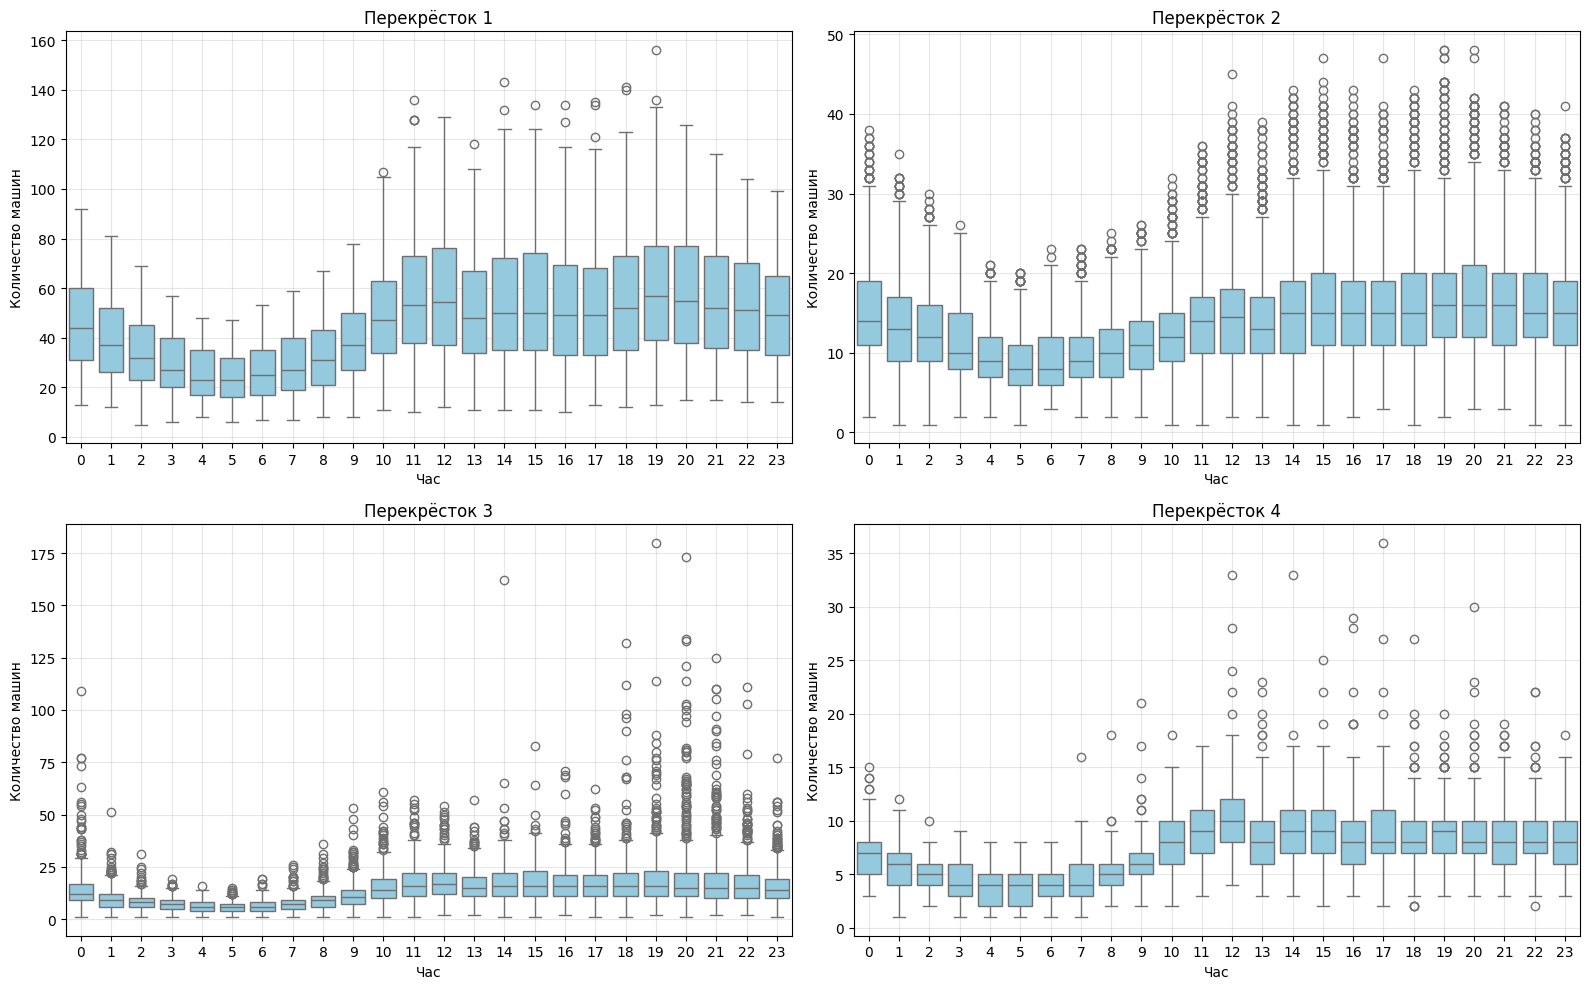

In [12]:
# загруженность перекрестков по часам
df_sorted['hour'] = df_sorted.index.hour
junctions = sorted(df_sorted['Junction'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, junction in enumerate(junctions):
    data = df_sorted[df_sorted['Junction'] == junction]
    sns.boxplot(data=data, x='hour', y='Vehicles', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Перекрёсток {junction}', fontsize=12)
    axes[i].set_xlabel('Час')
    axes[i].set_ylabel('Количество машин')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Посмотрим загруженность перекрестков по времени суток.

По графикам видно, что динамика изменения трафика относительно идентична: спад на 4-5-ти, плавный подъем, пик на 11-12-ти и медленный спад до 4-5-ти.

In [13]:
# праздники
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())

# 0 - обычный день, 1 - праздник или выходной
df['is_holiday_or_weekend'] = (
    df.index.isin(holidays) | (df.index.dayofweek >= 5)
).astype(int)

print(df[['Vehicles', 'is_holiday_or_weekend']].head(5))

print("\nКоличество дней по типам:")
print(df['is_holiday_or_weekend'].value_counts().sort_index())

df.head()

                     Vehicles  is_holiday_or_weekend
DateTime                                            
2015-11-01 00:00:00        15                      1
2015-11-01 00:00:00         6                      1
2015-11-01 00:00:00         9                      1
2015-11-01 01:00:00         7                      1
2015-11-01 01:00:00        13                      1

Количество дней по типам:
is_holiday_or_weekend
0    34385
1    13735
Name: count, dtype: int64


,Junction,Vehicles,is_holiday_or_weekend
DateTime,,,
2015-11-01 00:00:00,1,15,1
2015-11-01 00:00:00,2,6,1
2015-11-01 00:00:00,3,9,1
2015-11-01 01:00:00,3,7,1
2015-11-01 01:00:00,1,13,1


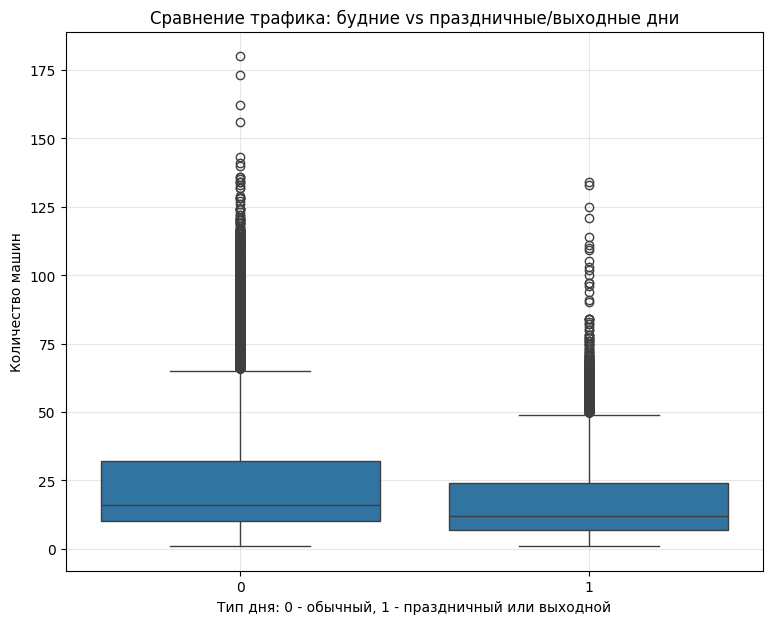

In [18]:
plt.figure(figsize=(9, 7))
sns.boxplot(data=df, x='is_holiday_or_weekend', y='Vehicles')
plt.title('Сравнение трафика: будние vs праздничные/выходные дни')
plt.xlabel('Тип дня: 0 - обычный, 1 - праздничный или выходной')
plt.ylabel('Количество машин')
plt.grid(True, alpha=0.3)
plt.tight_layout
plt.show()

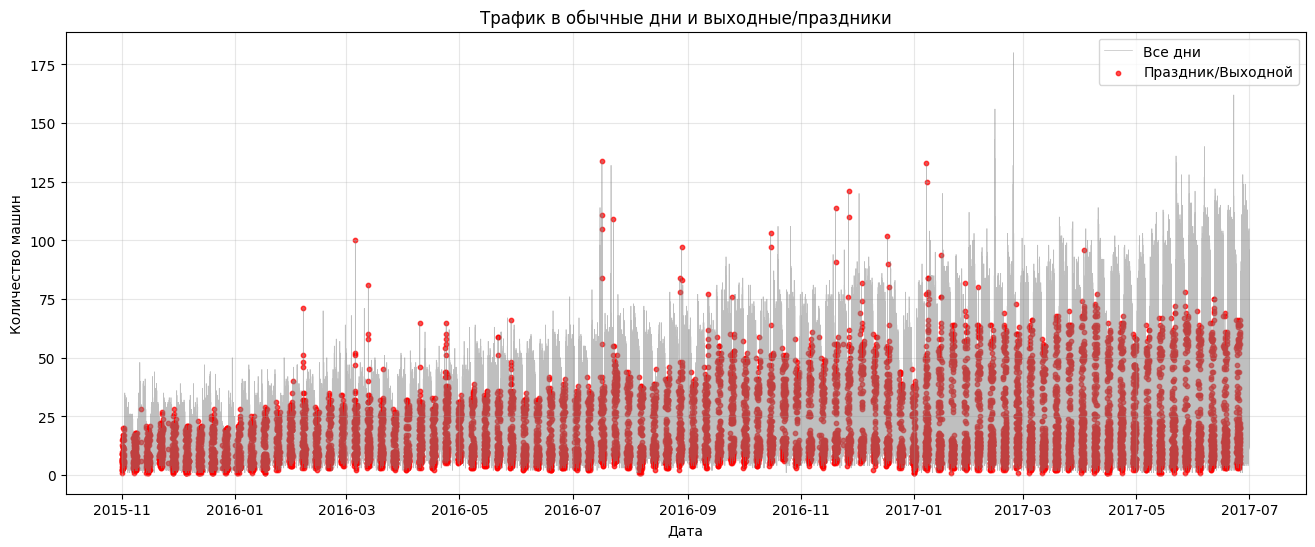

In [19]:
plt.figure(figsize=(16, 6))

plt.plot(df.index, df['Vehicles'], linewidth=0.5, alpha=0.5, color='gray', label='Все дни')

holiday_data = df[df['is_holiday_or_weekend'] == 1]
plt.scatter(holiday_data.index, holiday_data['Vehicles'],
            color='red', s=10, alpha=0.7, label='Праздник/Выходной')

plt.title('Трафик в обычные дни и выходные/праздники')
plt.xlabel('Дата')
plt.ylabel('Количество машин')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Декомпозиция ВР

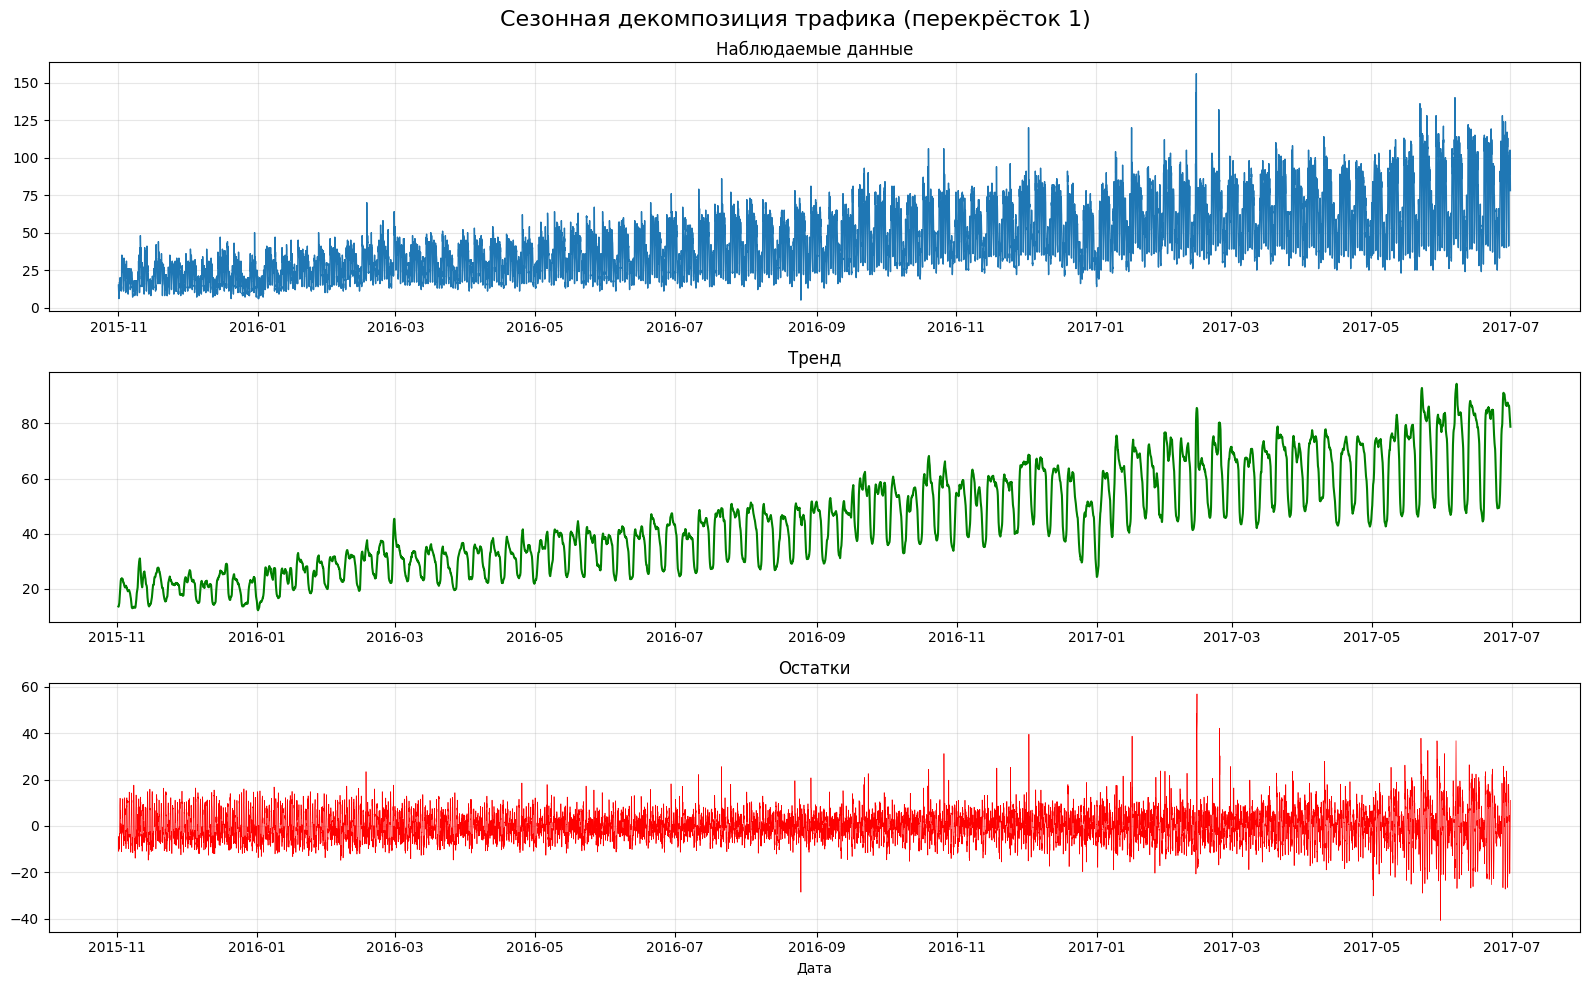

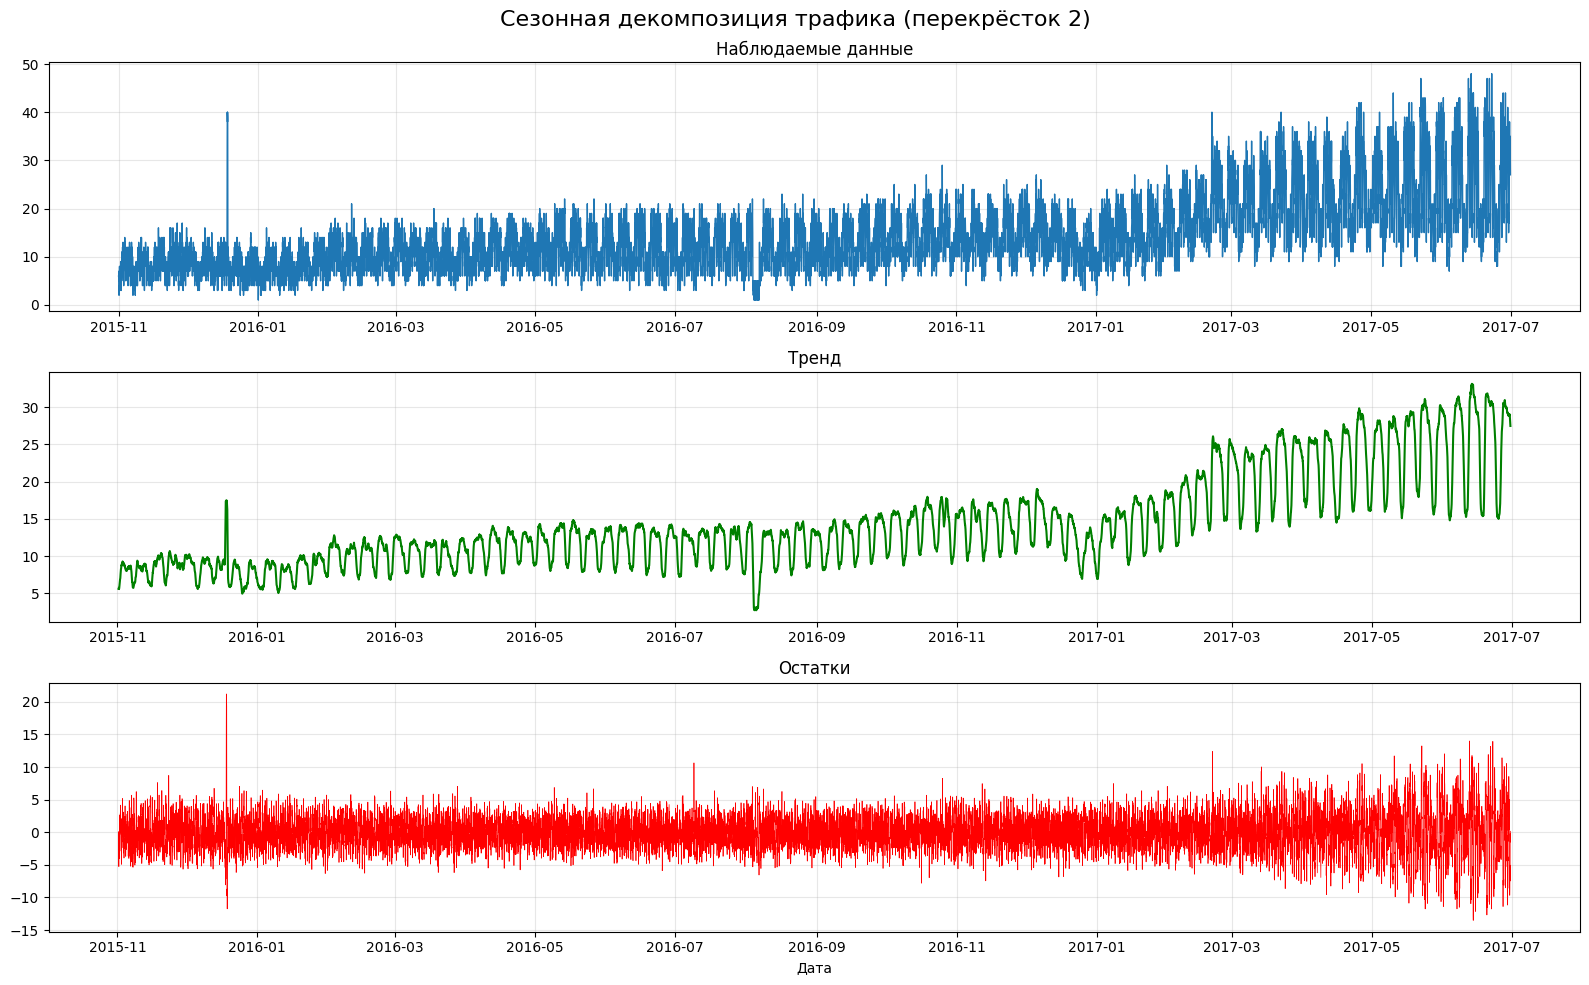

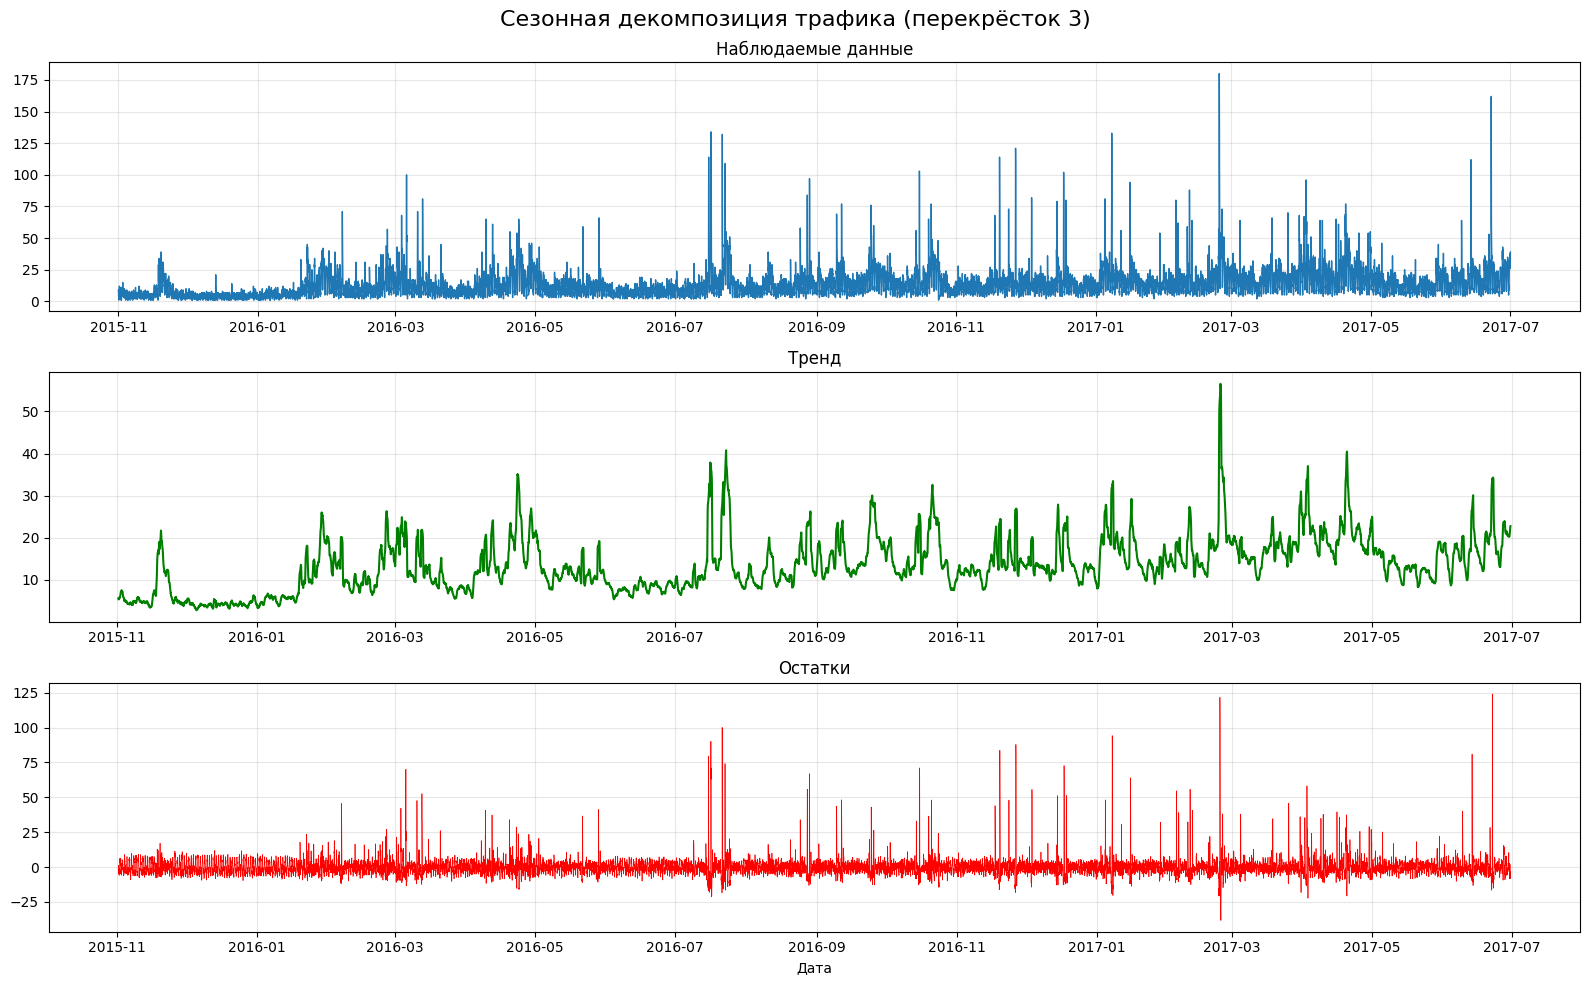

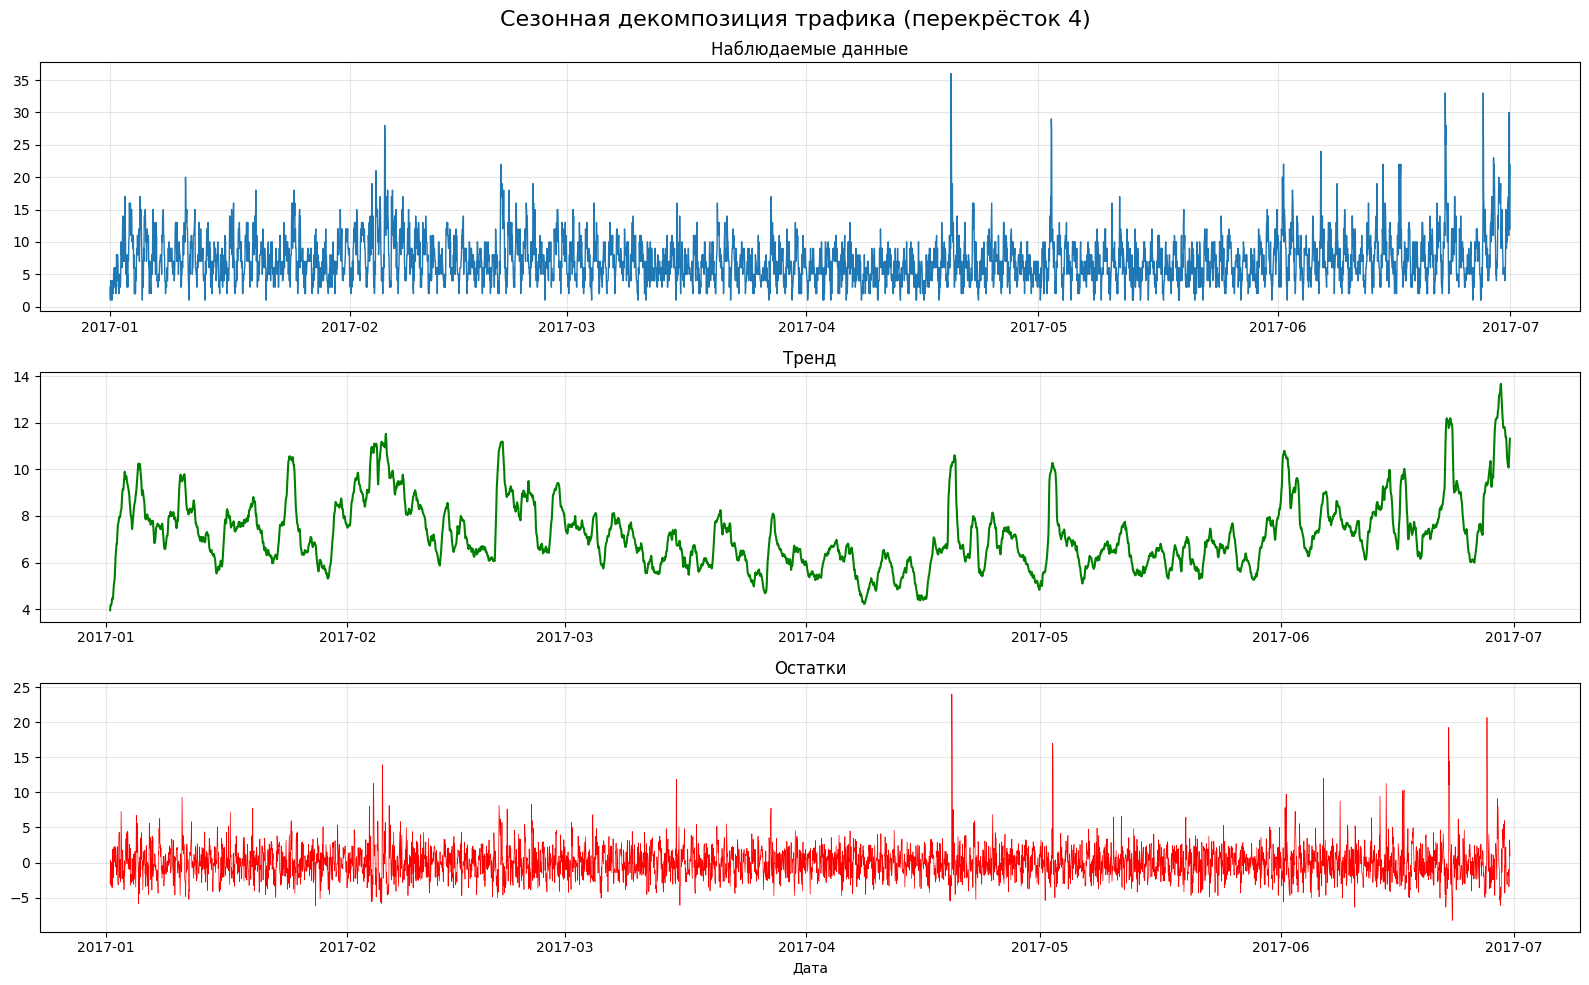

In [20]:
# statsmodel
for i in junctions:
  junction_id = i
  data = df[df['Junction'] == junction_id]['Vehicles'].copy()

  decomp = seasonal_decompose(data, model='additive', period=24)

  # Визуализация
  fig, axes = plt.subplots(3, 1, figsize=(16, 10))
  fig.suptitle(f'Сезонная декомпозиция трафика (перекрёсток {junction_id})', fontsize=16)

  # данные
  axes[0].plot(decomp.observed, linewidth=1)
  axes[0].set_title('Наблюдаемые данные')
  axes[0].grid(True, alpha=0.3)

  # тренд
  axes[1].plot(decomp.trend, linewidth=1.5, color='green')
  axes[1].set_title('Тренд')
  axes[1].grid(True, alpha=0.3)

  # остатки
  axes[2].plot(decomp.resid, linewidth=0.5, color='red')
  axes[2].set_title('Остатки')
  axes[2].set_xlabel('Дата')
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

In [31]:
# создаём отдельные датафреймы для каждого перекрестка
df_junction_1 = df[df['Junction'] == junctions[0]].copy()
df_junction_2 = df[df['Junction'] == junctions[1]].copy()
df_junction_3 = df[df['Junction'] == junctions[2]].copy()
df_junction_4 = df[df['Junction'] == junctions[3]].copy()

df_list = [df_junction_1, df_junction_2, df_junction_3, df_junction_4]

# удаляем колонку Junction из каждого
df_junction_1 = df_junction_1.drop('Junction', axis=1)
df_junction_2 = df_junction_2.drop('Junction', axis=1)
df_junction_3 = df_junction_3.drop('Junction', axis=1)
df_junction_4 = df_junction_4.drop('Junction', axis=1)

df_junction_4.head(3)

,Vehicles,is_holiday_or_weekend
DateTime,,
2017-01-01 00:00:00,3,1
2017-01-01 01:00:00,1,1
2017-01-01 02:00:00,4,1


In [33]:
# проверка стационарности
def check_stationarity(series):
    """
    Проверяет стационарность ряда с помощью тестов ADF и KPSS
    """
    print(f"\nПроверка стационарности")

    # Тест ADF
    adf_result = adfuller(series, autolag='AIC')
    print(f"\nТест ADF:")
    print(f"  Статистика: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Критические значения:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.4f}")

    if adf_result[1] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд НЕ стационарен (не отвергаем H0)")

    # Тест KPSS
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"\nТест KPSS:")
    print(f"  Статистика: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Критические значения:")
    for key, value in kpss_result[3].items():
        print(f"    {key}: {value:.4f}")

    if kpss_result[1] > 0.05:
        print("Ряд стационарен (не отвергаем H0)")
    else:
        print("Ряд НЕ стационарен (отвергаем H0)")

    return adf_result[1] < 0.05 and kpss_result[1] > 0.05

In [34]:
for i in df_list:
  check_stationarity(i['Vehicles'])


Проверка стационарнсти

Тест ADF:
  Статистика: -7.1481
  p-value: 0.0000
  Критические значения:
    1%: -3.4308
    5%: -2.8617
    10%: -2.5669
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 18.7477
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)

Проверка стационарнсти


/tmp/ipykernel_89149/1688042244.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')



Тест ADF:
  Статистика: -8.0411
  p-value: 0.0000
  Критические значения:
    1%: -3.4308
    5%: -2.8617
    10%: -2.5669
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 15.1994
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)

Проверка стационарнсти


/tmp/ipykernel_89149/1688042244.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')



Тест ADF:
  Статистика: -8.2366
  p-value: 0.0000
  Критические значения:
    1%: -3.4308
    5%: -2.8617
    10%: -2.5669
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 7.3218
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)

Проверка стационарнсти


/tmp/ipykernel_89149/1688042244.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')



Тест ADF:
  Статистика: -6.7267
  p-value: 0.0000
  Критические значения:
    1%: -3.4319
    5%: -2.8622
    10%: -2.5671
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 0.9476
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)


/tmp/ipykernel_89149/1688042244.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')
